In [30]:
# ============================================
# CELL 1: IMPORTS
# ============================================
import pandas as pd
import numpy as np
import re
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter



In [31]:
df = pd.read_excel('DeepX_train.xlsx')
test_df = pd.read_excel('DeepX_unlabeled.xlsx')

print(f"Train size: {df.shape}")
print(f"Test size: {test_df.shape}")
print("\nColumns:", df.columns.tolist())
print("\nFirst row:")
df.head(2)

Train size: (1971, 9)
Test size: (7047, 7)

Columns: ['review_id', 'review_text', 'star_rating', 'date', 'business_name', 'business_category', 'platform', 'aspects', 'aspect_sentiments']

First row:


,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."


In [32]:
# ============================================
# CELL 3: PARSE ASPECTS & SENTIMENTS
# ============================================
def parse_list_column(val):
    try:
        return ast.literal_eval(val)
    except:
        try:
            return json.loads(val)
        except:
            return ['none']

def parse_dict_column(val):
    try:
        return ast.literal_eval(val)
    except:
        try:
            return json.loads(val)
        except:
            return {'none': 'neutral'}

df['aspects'] = df['aspects'].apply(parse_list_column)
df['aspect_sentiments'] = df['aspect_sentiments'].apply(parse_dict_column)

print("✅ Parsed!")
print("\nSample aspects:", df['aspects'].head(3).tolist())
print("Sample sentiments:", df['aspect_sentiments'].head(3).tolist())

✅ Parsed!

Sample aspects: [['app_experience', 'delivery'], ['cleanliness', 'ambiance', 'service'], ['service', 'delivery', 'food']]
Sample sentiments: [{'app_experience': 'negative', 'delivery': 'negative'}, {'cleanliness': 'positive', 'ambiance': 'positive', 'service': 'positive'}, {'service': 'negative', 'delivery': 'negative', 'food': 'neutral'}]


In [33]:
# ============================================
# CELL 4: CLEAN ARABIC TEXT
# ============================================
def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove hashtags and mentions
    text = re.sub(r'#\w+|@\w+', '', text)
    
    # Remove repeated hashtag symbols (########)
    text = re.sub(r'#+', '', text)
    
    # Normalize Arabic characters
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)
    
    # Remove tashkeel
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    
    # Remove non Arabic/English but keep emojis
    text = re.sub(r'[^\u0600-\u06FF\u0750-\u077F\uFB50-\uFDFF\uFE70-\uFEFF'
                  r'a-zA-Z0-9\s\U0001F300-\U0001F9FF]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['clean_text'] = df['review_text'].apply(clean_arabic_text)
test_df['clean_text'] = test_df['review_text'].apply(clean_arabic_text)

print("✅ Text cleaned!")
print("\nBefore:", df['review_text'].iloc[5])
print("After: ", df['clean_text'].iloc[5])

✅ Text cleaned!

Before: لقد حملت تطبيق عن طريق مستر بيست واريد سيارة تيسلا
After:  لقد حملت تطبيق عن طريق مستر بيست واريد سياره تيسلا


In [34]:
# ============================================
# CELL 5: NOISE DETECTION
# ============================================
def is_noise(text):
    if not isinstance(text, str):
        return True
    if len(text.strip()) == 0:
        return True
    if len(text.strip()) < 3:
        return True
    if re.match(r'^[\d\s]+$', text.strip()):
        return True
    if re.match(r'^[^\u0600-\u06FFa-zA-Z]+$', text.strip()):
        return True
    return False

df['is_noise'] = df['clean_text'].apply(is_noise)
test_df['is_noise'] = test_df['clean_text'].apply(is_noise)

print(f"Train noise rows: {df['is_noise'].sum()}")
print(f"Test noise rows:  {test_df['is_noise'].sum()}")
print("\nSample noise rows:")
df[df['is_noise'] == True][['review_text', 'clean_text']].head(5)

Train noise rows: 7
Test noise rows:  119

Sample noise rows:


,review_text,clean_text
14,💙💙💙,💙💙💙
402,سئ,سئ
469,اه,اه
763,سئ,سئ
1199,👍👍👍👍👍,👍👍👍👍👍


C:\Users\dell\AppData\Local\Temp\ipykernel_37584\1227129575.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aspects_df, x='aspect', y='count', palette='viridis')


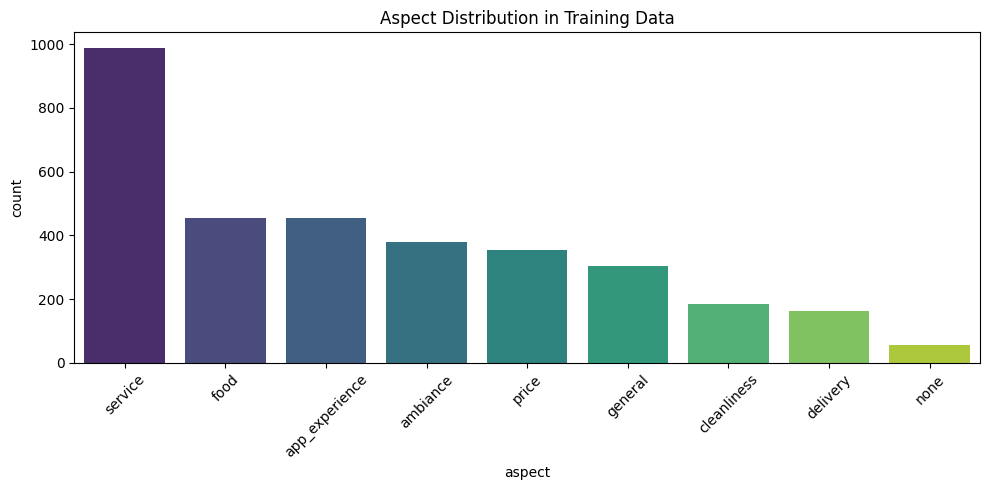

           aspect  count
4         service    988
5            food    454
0  app_experience    453
3        ambiance    378
7           price    354
6         general    303
2     cleanliness    185
1        delivery    161
8            none     57


In [35]:
# ============================================
# CELL 6: ASPECT DISTRIBUTION
# ============================================
aspect_counts = Counter()
for aspects_list in df['aspects']:
    for aspect in aspects_list:
        aspect_counts[aspect] += 1

aspects_df = pd.DataFrame(
    aspect_counts.items(), 
    columns=['aspect', 'count']
).sort_values('count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=aspects_df, x='aspect', y='count', palette='viridis')
plt.title('Aspect Distribution in Training Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(aspects_df)

C:\Users\dell\AppData\Local\Temp\ipykernel_37584\3624194088.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sent_df, x='sentiment', y='count', palette='coolwarm')


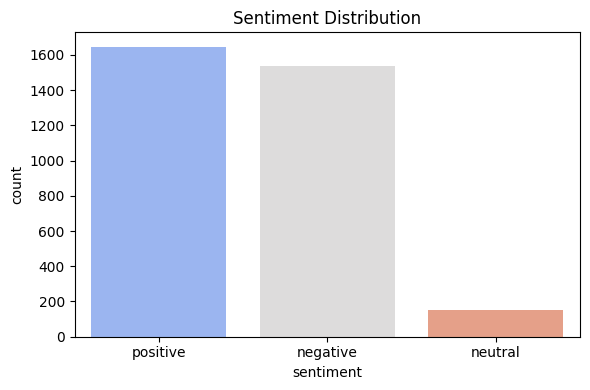

  sentiment  count
1  positive   1646
0  negative   1538
2   neutral    149


In [36]:
# ============================================
# CELL 7: SENTIMENT DISTRIBUTION
# ============================================
sentiment_counts = Counter()
for sent_dict in df['aspect_sentiments']:
    for sentiment in sent_dict.values():
        sentiment_counts[sentiment] += 1

sent_df = pd.DataFrame(
    sentiment_counts.items(),
    columns=['sentiment', 'count']
).sort_values('count', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=sent_df, x='sentiment', y='count', palette='coolwarm')
plt.title('Sentiment Distribution')
plt.tight_layout()
plt.show()

print(sent_df)

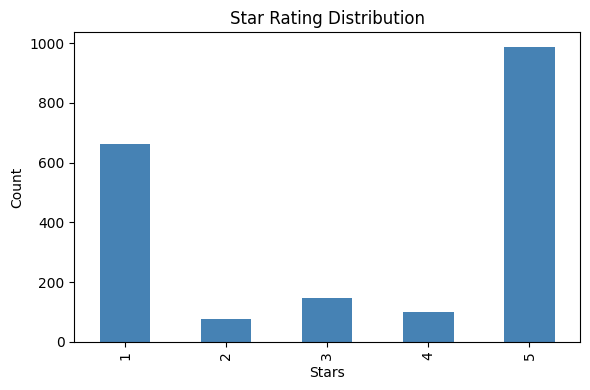

star_rating
1    661
2     78
3    146
4     99
5    987
Name: count, dtype: int64


In [37]:
# ============================================
# CELL 8: STAR RATING DISTRIBUTION
# ============================================
plt.figure(figsize=(6, 4))
df['star_rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Star Rating Distribution')
plt.xlabel('Stars')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['star_rating'].value_counts().sort_index())

📊 Train text length stats:
count    1971.000000
mean       21.920345
std        26.334615
min         1.000000
25%         7.000000
50%        14.000000
75%        27.000000
max       269.000000
Name: text_length, dtype: float64


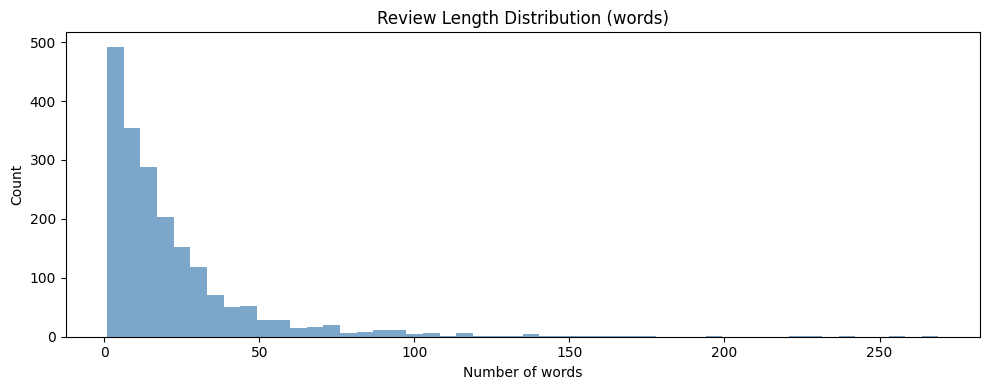

In [38]:
# ============================================
# CELL 9: REVIEW LENGTH ANALYSIS
# ============================================
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))
test_df['text_length'] = test_df['clean_text'].apply(lambda x: len(x.split()))

print("📊 Train text length stats:")
print(df['text_length'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['text_length'], bins=50, color='steelblue', alpha=0.7)
plt.title('Review Length Distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

📊 Number of aspects per review:
num_aspects
1    1066
2     552
3     266
4      71
5      15
6       1
Name: count, dtype: int64


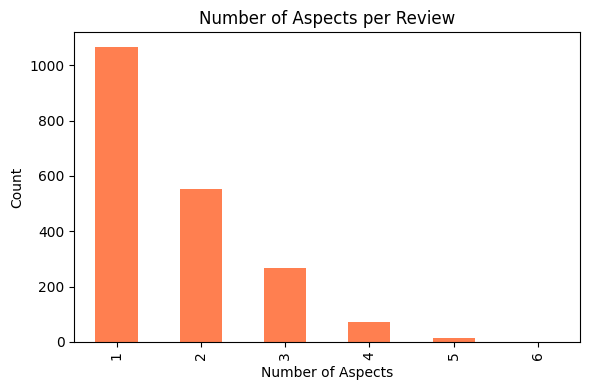

In [39]:
# ============================================
# CELL 11: MULTI-ASPECT REVIEWS ANALYSIS
# ============================================
df['num_aspects'] = df['aspects'].apply(len)

print("📊 Number of aspects per review:")
print(df['num_aspects'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df['num_aspects'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Number of Aspects per Review')
plt.xlabel('Number of Aspects')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [40]:
# Add to your preprocessing notebook

# CELL 13: HANDLE CLASS IMBALANCE
print("⚠️ Neutral sentiment is very rare!")
print("Solutions to add in model training:")
print("1. class_weight='balanced'")
print("2. Oversample neutral examples")
print("3. Lower threshold for neutral prediction")

# Check neutral examples
neutral_examples = []
for idx, row in df.iterrows():
    for aspect, sent in row['aspect_sentiments'].items():
        if sent == 'neutral':
            neutral_examples.append({
                'text': row['review_text'],
                'aspect': aspect,
                'sentiment': sent,
                'stars': row['star_rating']
            })

neutral_df = pd.DataFrame(neutral_examples)
print(f"\nTotal neutral cases: {len(neutral_df)}")
print("\nSample neutral reviews:")
print(neutral_df['text'].head(5).tolist())
print("\nStar ratings for neutral:")
print(neutral_df['stars'].value_counts())

⚠️ Neutral sentiment is very rare!
Solutions to add in model training:
1. class_weight='balanced'
2. Oversample neutral examples
3. Lower threshold for neutral prediction

Total neutral cases: 149

Sample neutral reviews:
['تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالولي نص ساعة فعد ساعة ونص\nالاكل يعني كويس ولكن كمية قليلة جدا', 'لقد حملت تطبيق عن طريق مستر بيست واريد سيارة تيسلا', 'مطعم محترم والخدمه محترمه جدا والاكل كويس والاسعار مابقتش تفرق كتير', 'الصراحه هو تطبيق حلو وكل حاجه بس لو رجع زي زمان زمان كان تقدر ترجع وتسرع برحتك في الأغنية وكمان ممكن تحمل الاغنية الي انت عاوزها', 'البوتيك حلو  يستحق الزياره بس موقعه غلط هو قدام مطعم ذا مود يارب تنتبهون']

Star ratings for neutral:
stars
5    70
3    35
4    22
1    13
2     9
Name: count, dtype: int64


Top aspect-sentiment combinations:
                combination  count
4          service_positive    529
5          service_negative    449
0   app_experience_negative    327
3         ambiance_positive    268
7          general_positive    255
8             food_positive    246
12           price_negative    233
14            food_negative    177
1         delivery_negative    142
11  app_experience_positive    111
9            price_positive    110
2      cleanliness_positive    109
17        ambiance_negative    101
15     cleanliness_negative     75
10             none_neutral     57


C:\Users\dell\AppData\Local\Temp\ipykernel_37584\2846113153.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


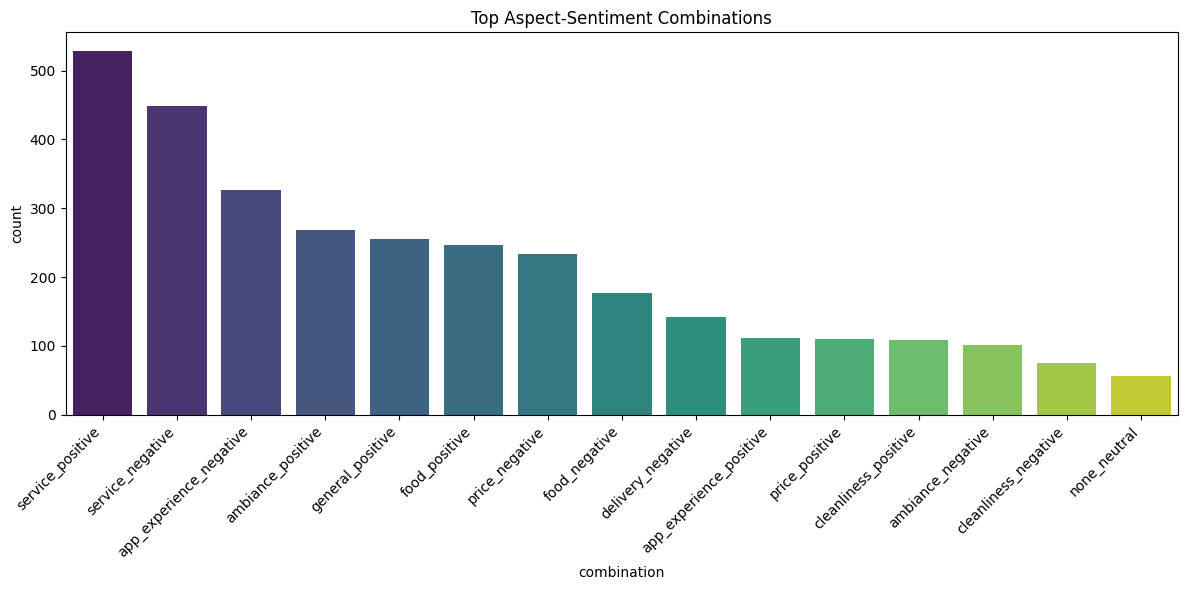

In [41]:
# ============================================
# CELL 14: ASPECT + SENTIMENT COMBINATIONS
# ============================================
combinations = Counter()
for idx, row in df.iterrows():
    for aspect, sent in row['aspect_sentiments'].items():
        combinations[f"{aspect}_{sent}"] += 1

combo_df = pd.DataFrame(
    combinations.items(),
    columns=['combination', 'count']
).sort_values('count', ascending=False)

print("Top aspect-sentiment combinations:")
print(combo_df.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=combo_df.head(15), 
    x='combination', 
    y='count',
    palette='viridis'
)
plt.xticks(rotation=45, ha='right')
plt.title('Top Aspect-Sentiment Combinations')
plt.tight_layout()
plt.show()

Stars vs Sentiment:
sentiment  negative  neutral  positive
stars                                 
1              1185       13        35
2               104        9        22
3               137       35        84
4                50       22       110
5                62       70      1395


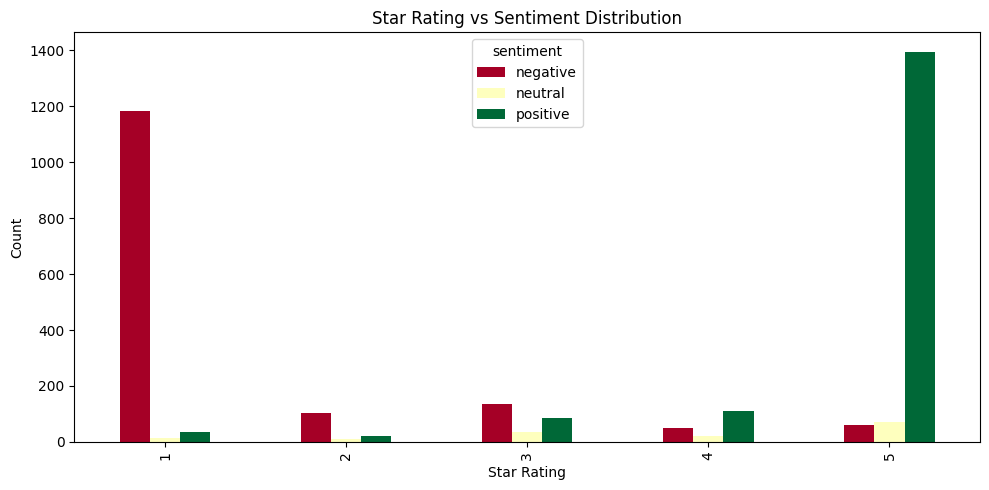

In [42]:
# ============================================
# CELL 15: STAR RATING VS SENTIMENT
# ============================================
# Does star rating align with sentiment?
rows = []
for idx, row in df.iterrows():
    for aspect, sent in row['aspect_sentiments'].items():
        rows.append({
            'stars': row['star_rating'],
            'sentiment': sent
        })

rating_sent_df = pd.DataFrame(rows)

cross = pd.crosstab(
    rating_sent_df['stars'], 
    rating_sent_df['sentiment']
)

print("Stars vs Sentiment:")
print(cross)

cross.plot(kind='bar', figsize=(10,5), colormap='RdYlGn')
plt.title('Star Rating vs Sentiment Distribution')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [43]:
# ============================================
# CELL 16: PREPARE FINAL CLEAN DATASET
# ============================================
VALID_ASPECTS = [
    'food', 'service', 'price', 'cleanliness',
    'delivery', 'ambiance', 'app_experience', 
    'general', 'none'
]
VALID_SENTIMENTS = ['positive', 'negative', 'neutral']

def validate_row(row):
    """Check if aspects and sentiments are valid"""
    for aspect in row['aspects']:
        if aspect not in VALID_ASPECTS:
            return False
    for aspect, sent in row['aspect_sentiments'].items():
        if sent not in VALID_SENTIMENTS:
            return False
        if aspect not in VALID_ASPECTS:
            return False
    return True

df['is_valid'] = df.apply(validate_row, axis=1)
print(f"Valid rows: {df['is_valid'].sum()}")
print(f"Invalid rows: {(~df['is_valid']).sum()}")

# Show invalid rows if any
if (~df['is_valid']).sum() > 0:
    print("\nInvalid rows:")
    print(df[~df['is_valid']][['review_text', 'aspects', 'aspect_sentiments']].head())

Valid rows: 1971
Invalid rows: 0


In [44]:
# ============================================
# CELL 17: SAVE FINAL STATS SUMMARY
# ============================================
print("="*50)
print("📊 FINAL DATA SUMMARY")
print("="*50)
print(f"Total train rows:     {len(df)}")
print(f"Total test rows:      {len(test_df)}")
print(f"Noise rows (train):   {df['is_noise'].sum()}")
print(f"Noise rows (test):    {test_df['is_noise'].sum()}")
print(f"\nAspect counts:")
for aspect, count in sorted(aspect_counts.items(), 
                             key=lambda x: x[1], reverse=True):
    bar = '█' * (count // 50)
    print(f"  {aspect:<20} {count:>4} {bar}")
print(f"\nSentiment counts:")
print(f"  positive: {sentiment_counts['positive']}")
print(f"  negative: {sentiment_counts['negative']}")
print(f"  neutral:  {sentiment_counts['neutral']} ⚠️ Very few!")
print("\n⚠️ KEY ISSUES TO HANDLE:")
print("  1. Neutral class very imbalanced (149 only)")
print("  2. none aspect very rare (57 only)")
print("  3. cleanliness and delivery are weak")
print("\n✅ Preprocessing notebook complete!")

📊 FINAL DATA SUMMARY
Total train rows:     1971
Total test rows:      7047
Noise rows (train):   7
Noise rows (test):    119

Aspect counts:
  service               988 ███████████████████
  food                  454 █████████
  app_experience        453 █████████
  ambiance              378 ███████
  price                 354 ███████
  general               303 ██████
  cleanliness           185 ███
  delivery              161 ███
  none                   57 █

Sentiment counts:
  positive: 1646
  negative: 1538
  neutral:  149 ⚠️ Very few!

⚠️ KEY ISSUES TO HANDLE:
  1. Neutral class very imbalanced (149 only)
  2. none aspect very rare (57 only)
  3. cleanliness and delivery are weak

✅ Preprocessing notebook complete!


In [45]:
# ============================================
# CELL 15: SAVE CLEANED DATA TO XLSX FILES
# ============================================
df.to_excel('DeepX_train_cleaned.xlsx', index=False)
test_df.to_excel('DeepX_unlabeled_cleaned.xlsx', index=False)

print("✅ Cleaned data saved to XLSX files!")
print("  - Train data: DeepX_train_cleaned.xlsx")
print("  - Test data: DeepX_unlabeled_cleaned.xlsx")

✅ Cleaned data saved to XLSX files!
  - Train data: DeepX_train_cleaned.xlsx
  - Test data: DeepX_unlabeled_cleaned.xlsx
